In [1]:
import os

def rename_subfolders(base_folder):
    # Get a list of all items in the base folder
    items = os.listdir(base_folder)
    
    # Filter out only directories (subfolders)
    subfolders = [item for item in items if os.path.isdir(os.path.join(base_folder, item))]
    
    # Sort the subfolders alphabetically (or use another sorting method if needed)
    subfolders.sort()
    
    # Rename each subfolder with a sequential number starting from 1
    for index, subfolder in enumerate(subfolders, start=1):
        old_path = os.path.join(base_folder, subfolder)
        new_name = str(index)  # Convert the index to a string to use as the new name
        new_path = os.path.join(base_folder, new_name)
        
        # Rename the subfolder
        os.rename(old_path, new_path)
        print(f"Renamed '{old_path}' to '{new_path}'")

# Example usage
base_folder = 'D:/Lectures/Final/codes/3D Layout GGEO/dataset/CSG_TEST'  # Replace with the path to your folder
rename_subfolders(base_folder)

Renamed 'D:/Lectures/Final/codes/3D Layout GGEO/dataset/CSG_TEST\1' to 'D:/Lectures/Final/codes/3D Layout GGEO/dataset/CSG_TEST\1'
Renamed 'D:/Lectures/Final/codes/3D Layout GGEO/dataset/CSG_TEST\35' to 'D:/Lectures/Final/codes/3D Layout GGEO/dataset/CSG_TEST\2'
Renamed 'D:/Lectures/Final/codes/3D Layout GGEO/dataset/CSG_TEST\4' to 'D:/Lectures/Final/codes/3D Layout GGEO/dataset/CSG_TEST\3'
Renamed 'D:/Lectures/Final/codes/3D Layout GGEO/dataset/CSG_TEST\56' to 'D:/Lectures/Final/codes/3D Layout GGEO/dataset/CSG_TEST\4'
Renamed 'D:/Lectures/Final/codes/3D Layout GGEO/dataset/CSG_TEST\66' to 'D:/Lectures/Final/codes/3D Layout GGEO/dataset/CSG_TEST\5'


In [ ]:
import os
import sys
import torch
import numpy as np
from PIL import Image

# Add the AdaBins folder to the Python path
sys.path.append(os.path.abspath("AdaBins"))
from infer import InferenceHelper

# Initialize the inference helper
infer_helper = InferenceHelper(dataset='nyu')

def read_image(img_path):
    """Read an image while handling IOError."""
    got_img = False
    while not got_img:
        try:
            img = Image.open(img_path).convert('RGB')
            got_img = True
        except IOError:
            print(f"IOError incurred when reading '{img_path}'. Retrying...")
            pass
    return img

def estimate_depth(img):
    """Estimate depth map using a pre-trained model."""
    bin_centers, predicted_depth = infer_helper.predict_pil(img)
    original_size = img.size
    
    # Convert predicted_depth to a tensor if it's not already
    predicted_depth_tensor = torch.tensor(predicted_depth[0][0])
    
    # Resize the predicted depth to the original image size
    prediction = torch.nn.functional.interpolate(
        predicted_depth_tensor.unsqueeze(0).unsqueeze(0),
        size=(original_size[1], original_size[0]),
        mode="bicubic",
        align_corners=False,
    ).squeeze()
    
    # Convert to NumPy array
    depth_map = prediction.cpu().numpy()
    
    # Normalize for visualization
    depth_map_normalized = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min())
    
    return depth_map, depth_map_normalized

base_folder = 'D:/Lectures/Final/codes/3D Layout GGEO/dataset/buildings_labels'
# Iterate over each folder in the base folder
for folder in os.listdir(base_folder):
    folder_path = os.path.join(base_folder, folder)
    if not os.path.isdir(folder_path):
        continue
    
    # Create a 'depth' subfolder if it doesn't exist
    depth_path = os.path.join(folder_path, 'depth')
    os.makedirs(depth_path, exist_ok=True)
    
    # Iterate over each image in the folder
    for image_name in os.listdir(folder_path):
        if not image_name.lower().endswith(('.jpg', '.png', '.jpeg')):
            continue
        
        image_path = os.path.join(folder_path, image_name)
        img = read_image(image_path)
        
        # Estimate the depth map
        depth_map, depth_map_normalized = estimate_depth(img)
        
        # Save original depth map as .npy
        depth_map_path = os.path.join(depth_path, os.path.splitext(image_name)[0] + '_depth.npy')
        np.save(depth_map_path, depth_map)
        print(f"Saved original depth map to {depth_map_path}")
        
        # Save normalized depth map as .png
        depth_map_scaled = (depth_map_normalized * 255).astype(np.uint8)
        depth_image = Image.fromarray(depth_map_scaled)
        depth_image_path = os.path.join(depth_path, os.path.splitext(image_name)[0] + '_depth.png')
        depth_image.save(depth_image_path)
        print(f"Saved normalized depth map to {depth_image_path}")

SyntaxError: invalid syntax (2157299764.py, line 19)

## Verify Dataset Loading :

In [1]:
from group_reid_dataset import GroupReIDDataset
from torchvision import transforms
from torch.utils.data import DataLoader
import os
import sys

# sys.path.append(os.path.abspath("/AdaBins"))

transform_g = transforms.Compose([
    transforms.Resize((256, 128)),  # Resize to a fixed size
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),          # Convert PIL image to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

transform_p = transforms.Compose([
    transforms.Resize((128, 64)),  # Resize to a fixed size
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),          # Convert PIL image to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

# Load Dataset
dataset = GroupReIDDataset(
    root_dir='buildings_labels',
    transform_g=transform_g,
    transform_p=transform_p,
    sigma=10
)

print(f"Total Entries: {len(dataset)}")
sample = dataset[50]
print("Group Image Shape:", sample[0].shape)  # Group image
print("Person Images Shape:", sample[2].shape)  # Padded person images (max_num x 3 x H x W)
print("Valid Person IDs:", sample[3])  # Valid person IDs
print("Sampled Layout Features:", sample[4])  # Sampled layout features
print("Mask:", sample[5])  # Mask for valid entries


Loading base model ()...

Using cache found in C:\Users\abhar/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


Done.
Removing last two layers (global_pool & classifier).
Building Encoder-Decoder model..

c:\Users\abhar\.conda\envs\mvision\Lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Done.


d:\Lectures\Final\codes\3D Layout GGEO\AdaBins\model_io.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(fpath, map_location='cpu')



Dataset Summary
----------------------------
Total Groups: 12
Total Images: 190
Total Entries: 190
Unique Person IDs: 54
Unique Group IDs: 12
----------------------------

Total Entries: 190


c:\Users\abhar\.conda\envs\mvision\Lib\site-packages\torch\nn\functional.py:5560: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)


Group Image Shape: torch.Size([3, 256, 128])
Person Images Shape: torch.Size([8, 3, 128, 64])
Valid Person IDs: [50, 51, 52, 53, 54, 55, -1, -1]
Sampled Layout Features: tensor([[ 5,  4,  5],
        [ 9,  4,  6],
        [ 9,  7,  5],
        [ 7,  8,  3],
        [ 5,  9,  2],
        [ 3,  9,  4],
        [-1, -1, -1],
        [-1, -1, -1]])
Mask: tensor([ True,  True,  True,  True,  True,  True, False, False])


In [2]:
# DataLoader
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, drop_last=True, num_workers=2)
for batch in dataloader:
    images, group_ids, person_imgs, valid_person_ids, sampled_layout_features, masks = batch
    print("Batch Images Shape:", images.shape)
    print("Batch Person Images Shape:", person_imgs.shape)
    print("Batch Masks:", masks)

Batch Images Shape: torch.Size([2, 3, 256, 128])
Batch Person Images Shape: torch.Size([2, 8, 3, 128, 64])
Batch Masks: tensor([[ True,  True,  True,  True,  True, False, False, False],
        [ True,  True,  True,  True,  True,  True, False, False]])
Batch Images Shape: torch.Size([2, 3, 256, 128])
Batch Person Images Shape: torch.Size([2, 8, 3, 128, 64])
Batch Masks: tensor([[ True,  True,  True,  True,  True,  True,  True, False],
        [ True,  True, False, False, False, False, False, False]])
Batch Images Shape: torch.Size([2, 3, 256, 128])
Batch Person Images Shape: torch.Size([2, 8, 3, 128, 64])
Batch Masks: tensor([[ True,  True,  True,  True, False, False, False, False],
        [ True,  True,  True,  True, False, False, False, False]])
Batch Images Shape: torch.Size([2, 3, 256, 128])
Batch Person Images Shape: torch.Size([2, 8, 3, 128, 64])
Batch Masks: tensor([[ True,  True,  True,  True,  True,  True, False, False],
        [ True,  True,  True,  True,  True,  True,  Tru

In [ ]:
import os
import sys
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

# Add the AdaBins folder to the Python path
sys.path.append(os.path.abspath("AdaBins"))
from infer import InferenceHelper
infer_helper = InferenceHelper(dataset='nyu')

def read_image(img_path):
    """Read an image while handling IOError."""
    got_img = False
    while not got_img:
        try:
            img = Image.open(img_path).convert('RGB')
            got_img = True
        except IOError:
            print(f"IOError incurred when reading '{img_path}'. Retrying...")
            pass
    return img

def estimate_depth(img):
    """Estimate depth map using a pre-trained model."""
    bin_centers, predicted_depth = infer_helper.predict_pil(img)
    original_size = img.size
    # Convert predicted_depth to a tensor if it's not already
    predicted_depth_tensor = torch.tensor(predicted_depth[0][0])
    # Resize the predicted depth to the original image size
    prediction = torch.nn.functional.interpolate(
        predicted_depth_tensor.unsqueeze(0).unsqueeze(0),  # Add batch and channel dimensions
        size=(original_size[1], original_size[0]),  # (height, width)
        mode="bicubic",
        align_corners=False,
    ).squeeze()  # Remove batch and channel dimensions
    depth_map = prediction.cpu().numpy()
    depth_map = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min())  # Normalize
    return depth_map

Loading base model ()...

Using cache found in C:\Users\abhar/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


Done.
Removing last two layers (global_pool & classifier).
Building Encoder-Decoder model..

c:\Users\abhar\.conda\envs\mvision\Lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Done.


d:\Lectures\Final\codes\3D Layout GGEO\AdaBins\model_io.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(fpath, map_location='cpu')


In [ ]:
img = read_image("D:/Lectures/Final/codes/3D Layout GGEO/test_imgs/s4.jpg")
output = estimate_depth(img)

In [ ]:
np.min(output), np.max(output)

(0.0, 1.0)

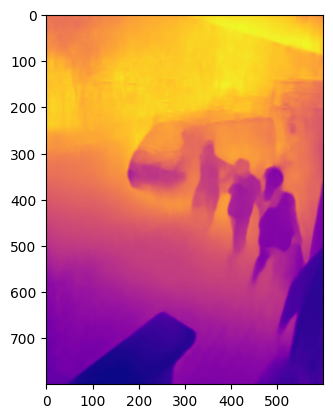

In [ ]:
plt.imshow(output, cmap='plasma')

In [ ]:
def calculate_average_depth(depth_map, bbox):
    """Calculate the average depth within a bounding box."""
    x, y, w, h = bbox
    depth_region = depth_map[y:y+h, x:x+w]
    return np.mean(depth_region)

def calculate_normalized_coordinates(bbox, img_size):
        """Calculate normalized center coordinates."""
        x, y, w, h = bbox
        img_w, img_h = img_size
        normalized_x = (x + w / 2) / img_w
        normalized_y = (y + h / 2) / img_h
        return normalized_x, normalized_y

In [ ]:
img_width, img_height = img.size
pixel_bboxes = []

x_center, y_center, width, height = 0.591667, 0.472500, 0.163333, 0.272500

x_min = int((x_center - width / 2) * img_width)
y_min = int((y_center - height / 2) * img_height)
box_width = int(width * img_width)
box_height = int(height * img_height)

pixel_bboxes.append((x_min, y_min, box_width, box_height, 0))


In [ ]:
pixel_bboxes

[(306, 268, 97, 218, 0)]

In [ ]:
for i, bbox in enumerate(pixel_bboxes):
    x, y, w, h, depth = bbox
    cropped_img = img.crop((x, y, x + w, y + h))

    avg_depth = calculate_average_depth(output, (x, y, w, h))
    normalized_coords = calculate_normalized_coordinates((x, y, w, h), img.size)

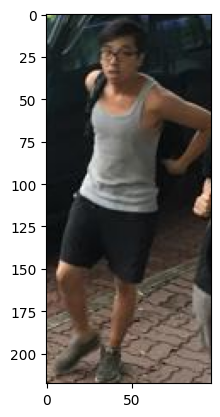

In [ ]:
plt.imshow(cropped_img)

In [ ]:
avg_depth, normalized_coords

(0.6034328, (0.5908333333333333, 0.47125))

# Compare diffrence of various Monocular Depth Estimation Models

![Screenshot 2025-02-03 153940.png](<attachment:Screenshot 2025-02-03 153940.png>)
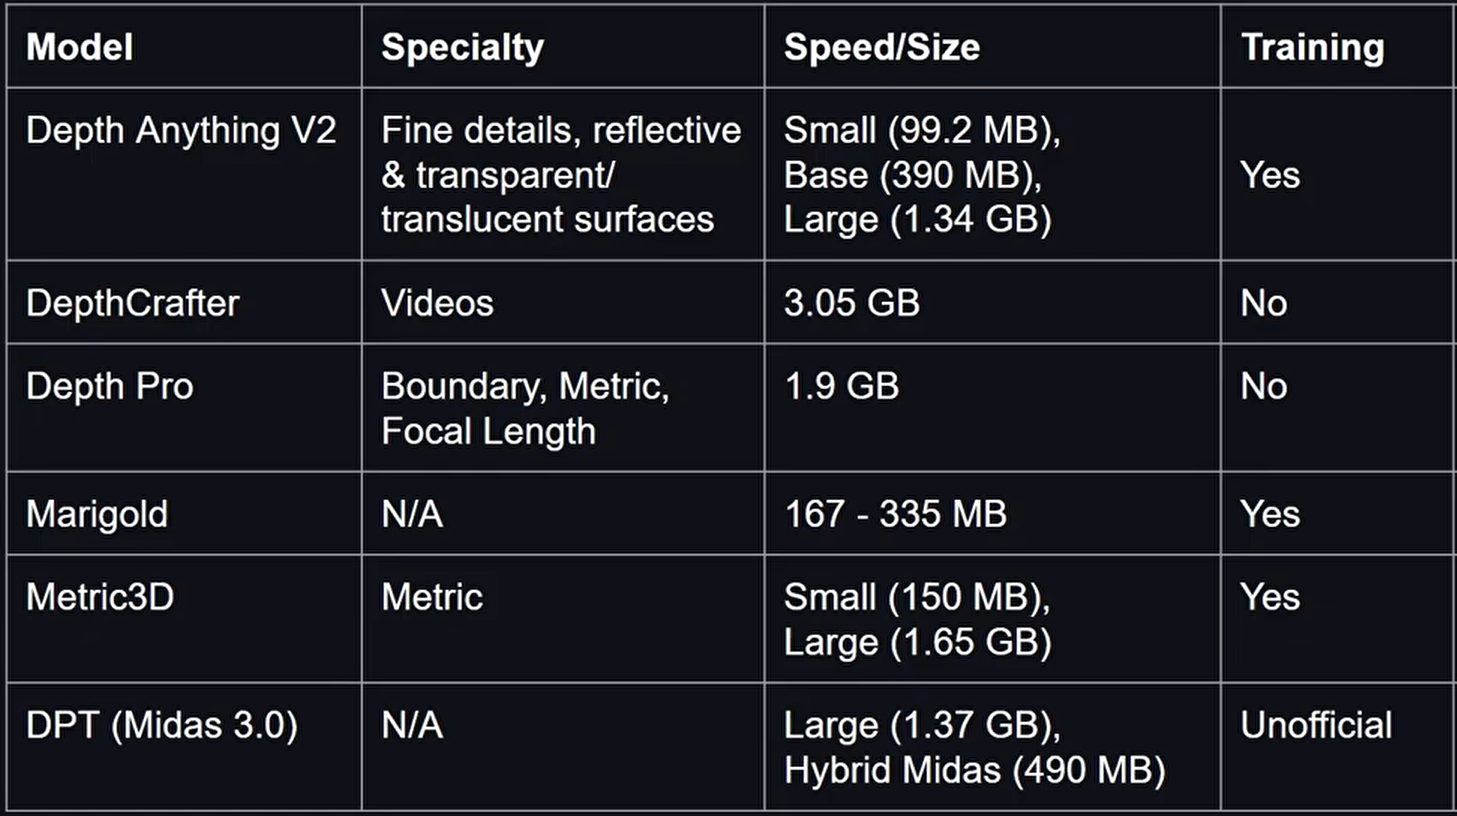

![moncular depth estimation 2.png](<attachment:moncular depth estimation 2.png>)
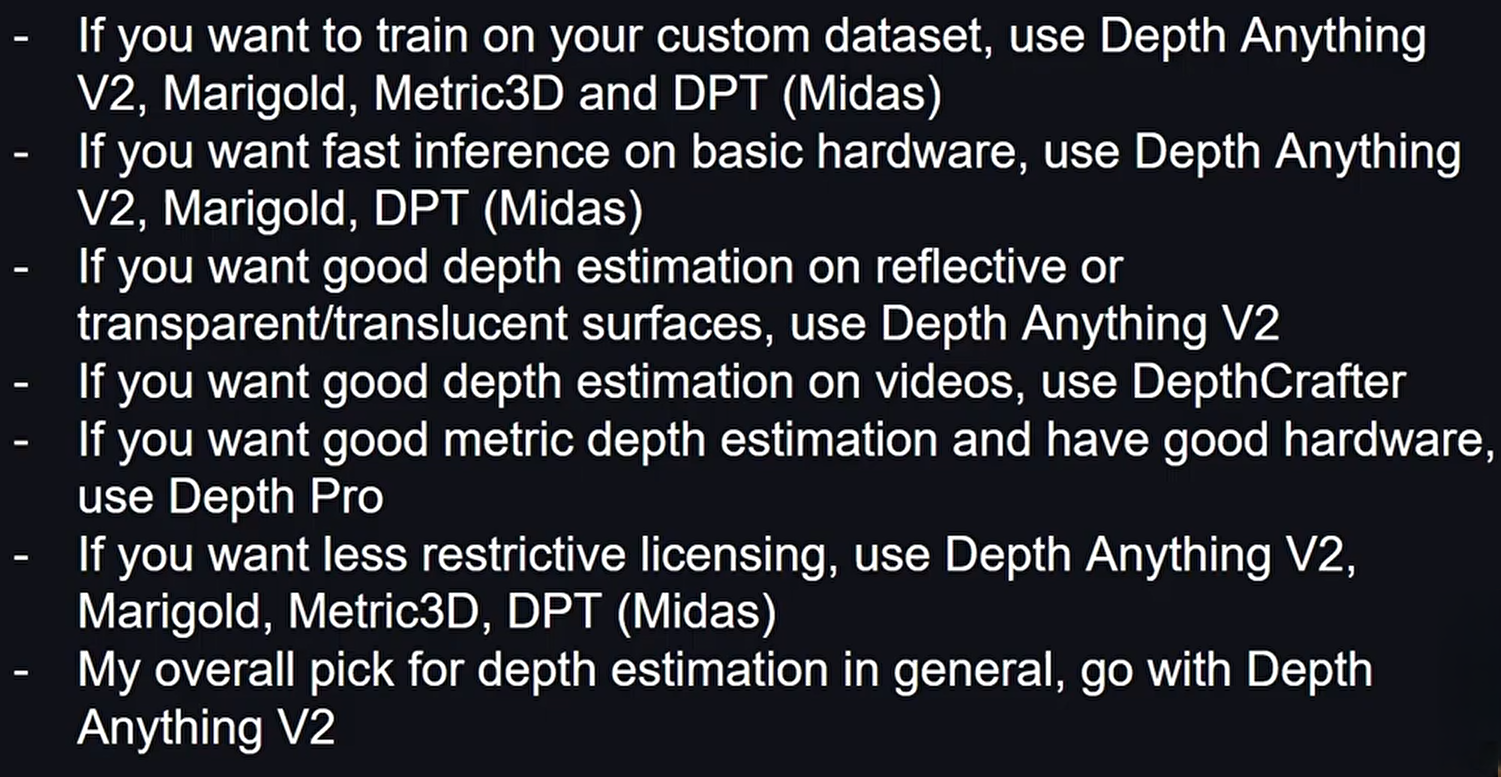

# 1- Inference Of MiDaS Monocular Depth Estimation
transofrmer based depth estimator

In [ ]:
# Download an image from the PyTorch homepage

import cv2
import torch
import urllib.request
import numpy as np

import matplotlib.pyplot as plt

# url, filename = ("https://github.com/pytorch/hub/raw/master/images/dog.jpg", "dog.jpg")
# urllib.request.urlretrieve(url, filename)

In [ ]:
# Load a model 
midas = torch.hub.load('intel-isl/MiDaS', 'DPT_Large')

# Move model to GPU if available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
midas.to(device)
midas.eval()

# Load transforms to resize and normalize the image for large or small model
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.dpt_transform


Using cache found in C:\Users\abhar/.cache\torch\hub\intel-isl_MiDaS_master
c:\Users\abhar\.conda\envs\mvision\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Using cache found in C:\Users\abhar/.cache\torch\hub\intel-isl_MiDaS_master


### Test 1

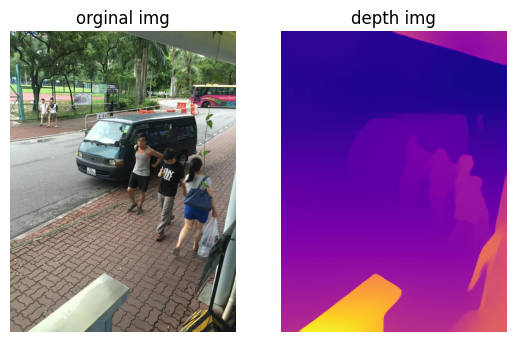

In [ ]:
# Load image and apply transforms
img = cv2.imread('D:/Lectures/Final/codes/3D Layout GGEO/test_imgs/s4.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_batch = transform(img).to(device)

# Predict and resize to original resolution
with torch.no_grad():
    prediction = midas(input_batch)

    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

output = prediction.cpu().numpy()

# Show result
plt.subplot(1,2,1)
plt.title('orginal img')
plt.imshow(img)
plt.axis('off')

plt.subplot(1,2,2)
plt.title('depth img')
plt.imshow(output, cmap='plasma')
plt.axis('off')

plt.show()

### Test 2

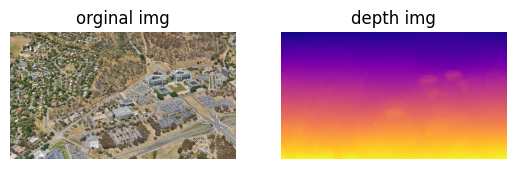

In [ ]:
# Load image and apply transforms
img = cv2.imread('D:/Lectures/Final/codes/3D Layout GGEO/test_imgs/building.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_batch = transform(img).to(device)

# Predict and resize to original resolution
with torch.no_grad():
    prediction = midas(input_batch)

    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

output = prediction.cpu().numpy()

# Show result
plt.subplot(1,2,1)
plt.title('orginal img')
plt.imshow(img)
plt.axis('off')

plt.subplot(1,2,2)
plt.title('depth img')
plt.imshow(output, cmap='plasma')
plt.axis('off')

plt.show()

In [ ]:
output.shape , img.shape

((729, 923), (729, 923, 3))

In [ ]:
np.min(output), np.max(output)

(1.0460293, 26.341587)

# 2- Inference Of Adabins Monocular Depth Estimation

In [ ]:
%cd AdaBins/

d:\Lectures\Final\codes\3D Layout GGEO\AdaBins


In [ ]:
from infer import InferenceHelper
from PIL import Image
import matplotlib.pyplot as plt
import torch

In [ ]:
"""
predictions using nyu dataset
"""
infer_helper = InferenceHelper(dataset='nyu')

Loading base model ()...

Using cache found in C:\Users\abhar/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


Done.
Removing last two layers (global_pool & classifier).
Building Encoder-Decoder model..

c:\Users\abhar\.conda\envs\mvision\Lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Done.


d:\Lectures\Final\codes\3D Layout GGEO\AdaBins\model_io.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(fpath, map_location='cpu')


### Test 1

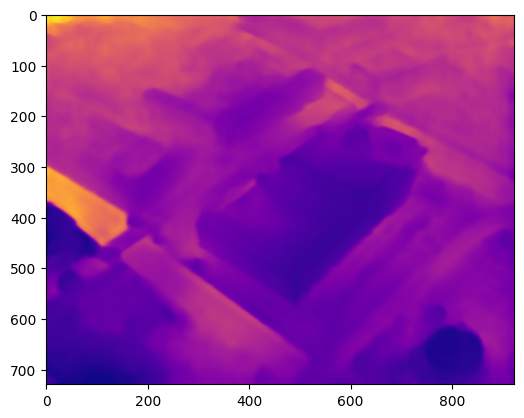

In [ ]:
# predict depth of a single pillow image
img = Image.open("D:/Lectures/Final/codes/3D Layout GGEO/test_imgs/image-9.png").convert('RGB')  # any rgb pillow image

bin_centers, predicted_depth = infer_helper.predict_pil(img)

original_size = img.size

# Convert predicted_depth to a tensor if it's not already
predicted_depth_tensor = torch.tensor(predicted_depth[0][0])

# Resize the predicted depth to the original image size
prediction = torch.nn.functional.interpolate(
    predicted_depth_tensor.unsqueeze(0).unsqueeze(0),  # Add batch and channel dimensions
    size=(original_size[1], original_size[0]),  # (height, width)
    mode="bicubic",
    align_corners=False,
).squeeze()  # Remove batch and channel dimensions

output = prediction.cpu().numpy()

plt.imshow(output, cmap='plasma')
plt.show()

In [ ]:
# .shape get (height, wideth, channel) and .size get (width, height, channel)
output.shape , img.size

((729, 923), (923, 729))

### Test 2

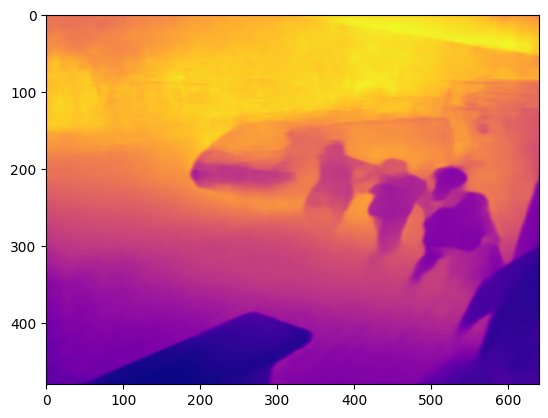

In [ ]:
# predict depth of a single pillow image
new_image = Image.open("D:/Lectures/Final/codes/3D Layout GGEO/test_imgs/s4.jpg").convert('RGB')  # any rgb pillow image

bin_centers, predicted_depth = infer_helper.predict_pil(new_image)

plt.imshow(predicted_depth[0][0], cmap='plasma')
plt.show()

In [ ]:
predicted_depth[0][0].shape, 

(480, 640)

# 3- Depth Anything V2

If you do not want to clone this repository, you can also load our models through <a link="https://github.com/huggingface/transformers/">Transformers</a>. Below is a simple code snippet. Please refer to the <a link="https://huggingface.co/docs/transformers/main/en/model_doc/depth_anything_v2">official page</a> for more details.

Note 1: Make sure you can connect to Hugging Face and have installed the latest Transformers.
Note 2: Due to the upsampling difference between OpenCV (we used) and Pillow (HF used), predictions may differ slightly. So you are more recommended to use our models through the way introduced above.

```python
from transformers import pipeline
from PIL import Image

pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Small-hf")
image = Image.open('your/image/path')
depth = pipe(image)["depth"]
```

### Fine-tuned to Metric Depth Estimation
Please refer to <a linl="https://github.com/DepthAnything/Depth-Anything-V2/blob/main/metric_depth">metric depth estimation</a>.

### DA-2K Evaluation Benchmark
Please refer to <a link="https://github.com/DepthAnything/Depth-Anything-V2/blob/main/DA-2K.md">DA-2K benchmark</a>.


میتوانیم مدل متریک رو برای ارتفاع های متفاوت با دیتاست خودمان فاین تیون کنیم 
باید مدل های آموزش دیده‌ش رو دانلود کنیم

```python
max_depth = 20 # 20 for indoor model, 80 for outdoor model
```

In [ ]:
%cd D:/Lectures/Final/codes/3D Layout GGEO/Depth-Anything-V2

D:\Lectures\Final\codes\3D Layout GGEO\Depth-Anything-V2


In [ ]:
import cv2
import torch

from depth_anything_v2.dpt import DepthAnythingV2

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}

encoder = 'vitl' # or 'vits', 'vitb', 'vitg'

model = DepthAnythingV2(**model_configs[encoder])
model.load_state_dict(torch.load(f'checkpoints/depth_anything_v2_{encoder}.pth', map_location='cpu'))
model = model.to(DEVICE).eval()



C:\Users\abhar\AppData\Local\Temp\ipykernel_38588\2795728676.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'checkpoints/depth_anythi

### Test 1

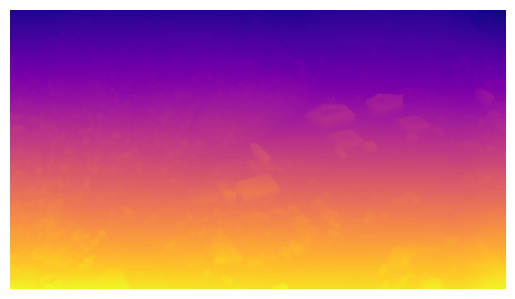

In [ ]:
raw_img = cv2.imread('D:/Lectures/Final/codes/3D Layout GGEO/test_imgs/building.png')
depth = model.infer_image(raw_img)

plt.imshow(depth, cmap='plasma')
plt.axis('off')
plt.show()

### Test 2

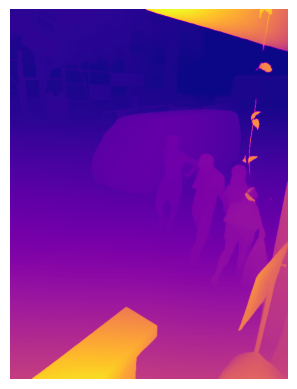

In [ ]:
raw_img = cv2.imread('D:/Lectures/Final/codes/3D Layout GGEO/test_imgs/s4.jpg')
depth = model.infer_image(raw_img)

plt.imshow(depth, cmap='plasma')
plt.axis('off')
plt.show()

In [ ]:
raw_img.shape, depth.shape

((800, 600, 3), (800, 600))

# 4- DepthCrafter: Generating Consistent Long Depth Sequences for Open-world Videos

- **DepthCrafter v1.0.1**:
    - Quality and speed improvement
        <table>
          <thead>
            <tr>
              <th>Method</th>
              <th>ms/frame&#x2193; @1024&#xD7;576 </th>
              <th colspan="2">Sintel (~50 frames)</th>
              <th colspan="2">Scannet (90 frames)</th>
              <th colspan="2">KITTI (110 frames)</th>
              <th colspan="2">Bonn (110 frames)</th>
            </tr>
            <tr>
                <th></th>
                <th></th>
              <th>AbsRel&#x2193;</th>
              <th>&delta;&#x2081; &#x2191;</th>
              <th>AbsRel&#x2193;</th>
              <th>&delta;&#x2081; &#x2191;</th>
              <th>AbsRel&#x2193;</th>
              <th>&delta;&#x2081; &#x2191;</th>
              <th>AbsRel&#x2193;</th>
              <th>&delta;&#x2081; &#x2191;</th>
            </tr>
          </thead>
          <tbody>
            <tr>
              <td>Marigold</td>
              <td>1070.29</td>
              <td>0.532</td>
              <td>0.515</td>
              <td>0.166</td>
              <td>0.769</td>
              <td>0.149</td>
              <td>0.796</td>
              <td>0.091</td>
              <td>0.931</td>
            </tr>
            <tr>
              <td>Depth-Anything-V2</td>
              <td><strong>180.46</strong></td>
              <td>0.367</td>
              <td>0.554</td>
              <td>0.135</td>
              <td>0.822</td>
              <td>0.140</td>
              <td>0.804</td>
              <td>0.106</td>
              <td>0.921</td>
            </tr>
            <tr>
              <td>DepthCrafter previous</td>
              <td>1913.92</td>
                <td><u>0.292</u></td>
                <td><strong>0.697</strong></td>
                <td><u>0.125</u></td>
                <td><u>0.848</u></td>
                <td><u>0.110</u></td>
                <td><u>0.881</u></td>
                <td><u>0.075</u></td>
                <td><u>0.971</u></td>
            </tr>
            <tr>
              <td>DepthCrafter v1.0.1</td>
              <td><u>465.84</u></td>
                <td><strong>0.270</strong></td>
                <td><strong>0.697</strong></td>
                <td><strong>0.123</strong></td>
                <td><strong>0.856</strong></td>
                <td><strong>0.104</strong></td>
                <td><strong>0.896</strong></td>
                <td><strong>0.071</strong></td>
                <td><strong>0.972</strong></td>
            </tr>
          </tbody>
        </table>

### This model suitable just for movie monocular depth estimation

# 5- Depth Pro: Sharp Monocular Metric Depth in Less Than a Second

this model present a foundation model for zero-shot metric monocular depth estimation. Our model, Depth Pro, synthesizes high-resolution depth maps with unparalleled sharpness and high-frequency details. The predictions are metric, with absolute scale, without relying on the availability of metadata such as camera intrinsics. And the model is fast, producing a 2.25-megapixel depth map in 0.3 seconds on a standard GPU. These characteristics are enabled by a number of technical contributions, including an efficient multi-scale vision transformer for dense prediction, a training protocol that combines real and synthetic datasets to achieve high metric accuracy alongside fine boundary tracing, dedicated evaluation metrics for boundary accuracy in estimated depth maps, and state-of-the-art focal length estimation from a single image.

The model in <a link="https://github.com/apple/ml-depth-pro">this repository</a> is a reference implementation, which has been re-trained. Its performance is close to the model reported in the paper but does not match it exactly.

# 6- Marigold: Repurposing Diffusion-Based Image Generators for Monocular Depth Estimation

this model is weak compare of others model that i checked them until now 

some results:
<table><tr>
<td> <img src="test_imgs/image-marigold.png" alt="Drawing" style="width: 250px;"/> </td>
<td> <img src="test_imgs/image-marigold2.png" alt="Drawing" style="width: 250px;"/> </td>
</tr></table>

time inference for avrage is 4 s

# 7- Metric3D
Metric3D is a strong and robust geometry foundation model for high-quality and zero-shot metric depth and surface normal estimation from a single image. It excels at solving in-the-wild scene reconstruction. It can directly help you measure the size of structures from a single image. Now it achieves SOTA performance on over 10 depth and normal benchmarks.

this model has several models:
- conv based model
- ViT based model
- ONNX based model
- various size of model: small, large and giant 
- KITTI fine-tuning code
- Supported models: metric3d_convnext_tiny, metric3d_convnext_large, metric3d_vit_small, metric3d_vit_large, metric3d_vit_giant2

Pytorch Hub is supported:

```python
import torch
model = torch.hub.load('yvanyin/metric3d', 'metric3d_vit_small', pretrain=True)
pred_depth, confidence, output_dict = model.inference({'input': rgb})
pred_normal = output_dict['prediction_normal'][:, :3, :, :] # only available for Metric3Dv2 i.e., ViT models
normal_confidence = output_dict['prediction_normal'][:, 3, :, :] # see https://arxiv.org/abs/2109.09881 for details
```

# 8- SelfSupervisedAerialDepthEstimator

this is <a link="https://github.com/Max-Hermann/SelfSupervisedAerialDepthEstimator"> github link </a> this project

this code needs Dataset for training that one of them is GTA game enviroment that use <a link="https://github.com/umautobots/GTAVisionExport">GTAVisionExport</a> scripts to get dataset of depth map and RGB images


results of syntic dataset (GTAV); firs row: RGB image , second row: predicted depth map, third row: ground truth (from GTAVisionExport)

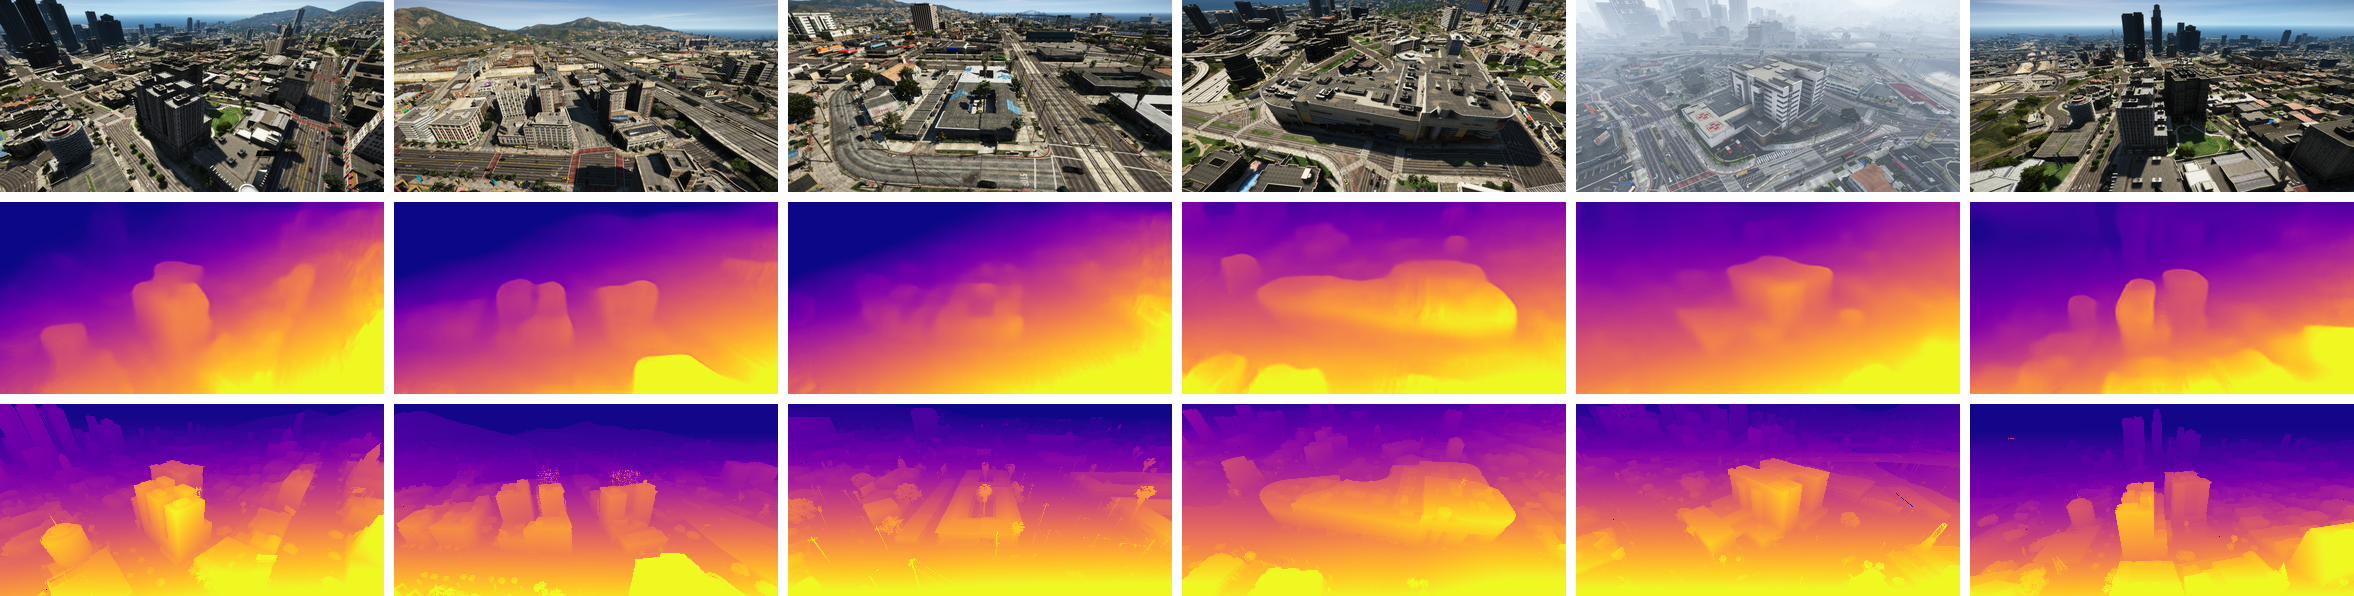

# 9- UseGeo Dataset

## Key Advantages of UseGeo for Depth Estimation

### High-Resolution Imagery
- **Image size**: 7952×5304 px (massive resolution for fine-grained depth prediction).
- **GSD**: 2 cm/pixel (exceptional detail for small objects and terrain).
- **Action**: Downsample images to a manageable size (e.g., 1989×1320 px) to match the depth maps, or use patch-based training.

### Rich Ground Truth
- **Depth maps (1/4 resolution)**: Directly usable for supervised training.
- **LiDAR point clouds**: Can be converted to denser depth maps if needed (e.g., using interpolation).
- **Camera poses/interior parameters**: Enable projection of LiDAR points to pixel-aligned depth maps for improved accuracy.

### Multi-View Overlap
- **80% forward / 60% side overlap**: Supports multi-view stereo (MVS) or self-supervised methods (e.g., Monodepth2) if monocular depth isn't sufficient.

### Real-World UAV Data
- **Captured at 80m altitude, covering 1100×650m**: Represents realistic drone scenarios, reducing the sim-to-real gap.

## How to Prepare UseGeo for Fine-Tuning

### 1. Preprocess Depth Maps
- **Align LiDAR and RGB data**: Use the provided camera poses to project LiDAR point clouds into depth maps aligned with images. Tools like COLMAP or Open3D can help.
- **Upsample depth maps**: If the 1989×1320 depth maps are too coarse, use super-resolution techniques or bilinear interpolation to match the image size.

### 2. Data Augmentation
- **Simulate altitude changes**: Use perspective warping to mimic flying at different heights (since altitude is fixed at 80m in the dataset).
- **Add motion blur**: UAVs often face motion artifacts; use `albumentations.MotionBlur()`.

### 3. Normalization
- Convert depth maps to metric units (meters) using the GSD (2 cm/pixel) and camera altitude (80m).
- **For example:**

    ```python
    depth_in_meters = (depth_pixels * GSD) / (focal_length_pixels) * altitude
    ```

### 4. Best Models for UseGeo
- **DPT (Vision Transformer)**
Why?

1. Handles high-resolution inputs (1989×1320) with its transformer architecture.
2. Pretrained on diverse datasets, but fine-tune on UseGeo’s metric depth maps.

- **AdaBins**
Why?

1. Predicts adaptive depth bins, ideal for large depth ranges (e.g., 0–1000m in UseGeo).

2. Achieves SOTA on NYU/KITTI and adapts well to aerial data.

Modification:

- Increase bin count (default: 256) to handle wider depth ranges.

- **MiDaS v3.1**
Why?

1. Lightweight and robust to scale variations.

2. Use the MiDaS-small variant for real-time UAV deployment.

3. Tip: Retrain with metric depth loss instead of relative depth.


### Training Workflow

- **Input Pipeline:**

- Resize images to 1989×1320 (or downsample further for faster training).

- Use camera intrinsics to correct depth maps for radial distortion.

- **Loss Function:**

- Scale-invariant logarithmic loss:
```python 
    def silog_loss(pred, target):
        log_diff = torch.log(pred) - torch.log(target)
        return torch.mean(log_diff**2) - 0.5 * (torch.mean(log_diff))**2
```

- Weighted RMSE: Penalize errors in high-gradient regions (e.g., building edges).

- **Fine-Tuning:**

- Start with pretrained weights (e.g., DPT-Hybrid).

- Freeze the encoder initially and train only the decoder.

### Final Recommendation
- For accuracy: DPT or AdaBins (use metric depth loss).
- For real-time: MiDaS-small (quantize with TensorRT).
